In [1]:
import numpy as np
import random 
import matplotlib.pyplot as plt 

In [23]:
#Making random x, y values, integer x and float ys
# 20 points 
X_rand = np.array([])
Y_rand = np.array([])

while np.size(X_rand) < 20:
    temp = random.randint(1,50)
    if temp in X_rand: 
        continue
    else: 
        X_rand = np.append(X_rand, temp)
        
for i in range(20):
    Y_rand = np.append(Y_rand, 10*random.random())

X_sort = np.sort(X_rand)

x = X_sort
y = Y_rand 

In [30]:
def error_func(x, y, coef):
    polynomial = np.poly1d(coef)
    y_pred = polynomial(x)
    
    # mean squared error 
    mse = np.mean((y-y_pred)**2)

    #r squared 
    ss_total = np.sum((y-np.mean(y))**2)
    ss_res = np.sum((y-y_pred)**2)
    r_squared = 1 - (ss_res/ss_total)
    return mse, r_squared, y_pred

In [31]:
#part a 

#linear
A = np.vstack([x, np.ones(len(x))]).T
coefficients_1 = np.linalg.lstsq(A, y, rcond=None)[0]

# cubic
degree = 3
coefficients_3 = np.polyfit(x, y, degree)

mse_1, rs_1, y_pred_1 = error_func(x, y, coefficients_1)
mse_3, rs_3, y_pred_3 = error_func(x, y, coefficients_3)

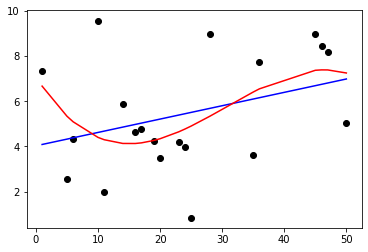

linear:
mean squared error: 5.4705
r squared:  0.1197

cubic:
mean squared error: 4.7209
r squared:  0.2403


In [32]:
plt.scatter(x, y, color="black")
plt.plot(x, y_pred_1, color="blue")
plt.plot(x, y_pred_3, color="red")
plt.show()
print(f'linear:\nmean squared error: {mse_1:0.4f}\nr squared: {rs_1: 0.4f}')
print(f'\ncubic:\nmean squared error: {mse_3:0.4f}\nr squared: {rs_3: 0.4f}')

Part a: Although both are poor fits, the cubic is a better fit 

/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


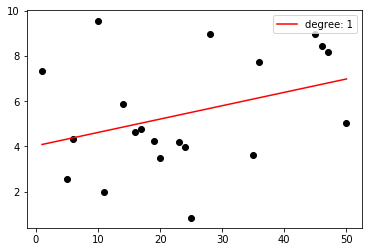

degree: 1
mean squared error: 5.4705
r squared:  0.1197


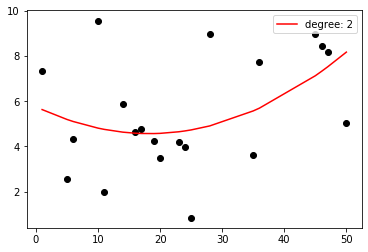

degree: 2
mean squared error: 4.9632
r squared:  0.2014


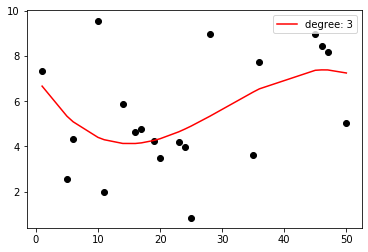

degree: 3
mean squared error: 4.7209
r squared:  0.2403


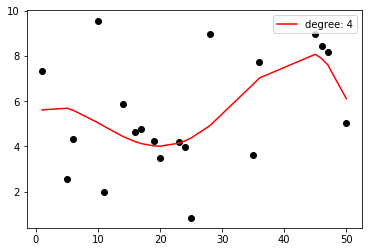

degree: 4
mean squared error: 4.4219
r squared:  0.2885


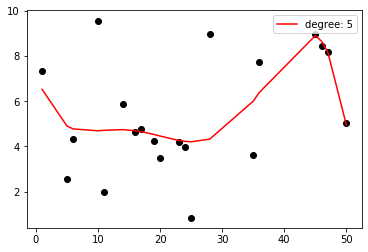

degree: 5
mean squared error: 4.0396
r squared:  0.3500


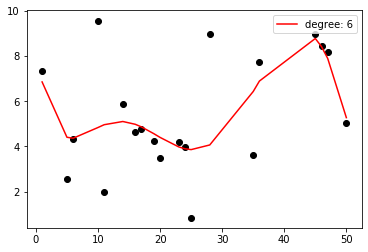

degree: 6
mean squared error: 3.9423
r squared:  0.3656


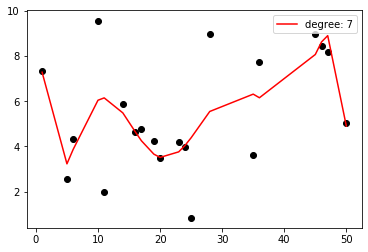

degree: 7
mean squared error: 3.3552
r squared:  0.4601


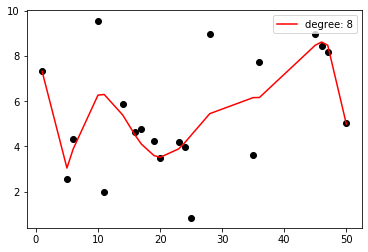

degree: 8
mean squared error: 3.3247
r squared:  0.4650


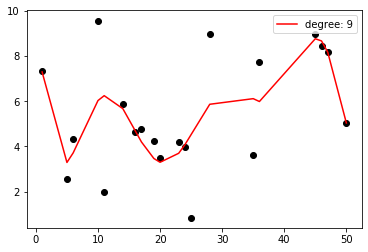

degree: 9
mean squared error: 3.2852
r squared:  0.4714


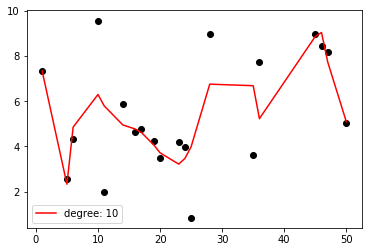

degree: 10
mean squared error: 2.9510
r squared:  0.5251


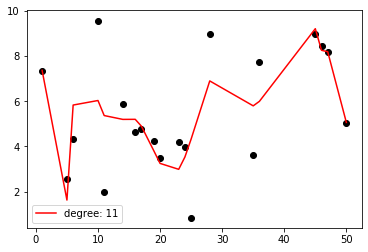

degree: 11
mean squared error: 2.7092
r squared:  0.5641


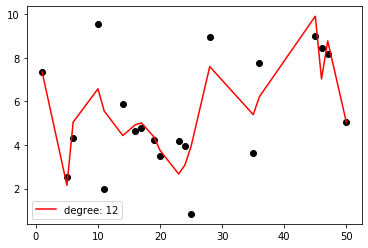

degree: 12
mean squared error: 2.4107
r squared:  0.6121


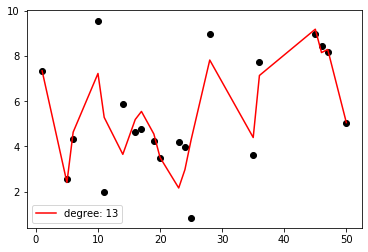

degree: 13
mean squared error: 2.1043
r squared:  0.6614


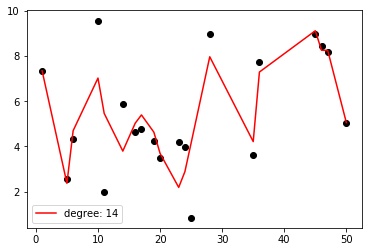

degree: 14
mean squared error: 2.0887
r squared:  0.6639


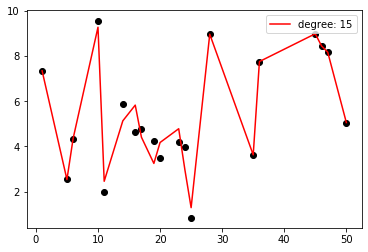

degree: 15
mean squared error: 0.2693
r squared:  0.9567


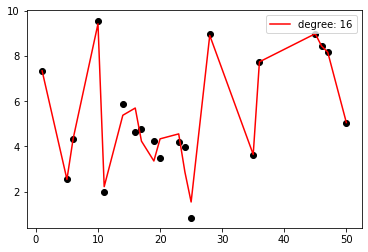

degree: 16
mean squared error: 0.2517
r squared:  0.9595


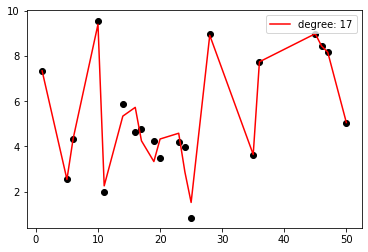

degree: 17
mean squared error: 0.2587
r squared:  0.9584


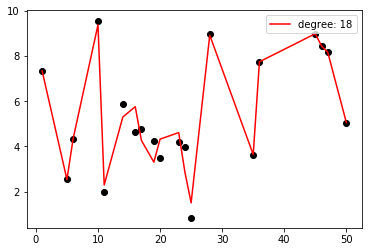

degree: 18
mean squared error: 0.2678
r squared:  0.9569


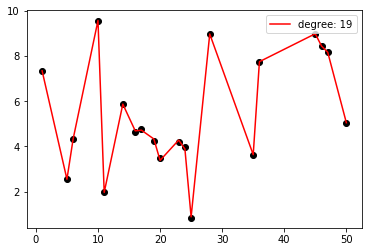

degree: 19
mean squared error: 0.0020
r squared:  0.9997


In [53]:
#part b

coefficients = [coefficients_1]
mse = [mse_1]
r_squared = [rs_1]
y_pred = [y_pred_1]

for i in range(2, 20): #how many degrees tested 
    coefficients.append(np.polyfit(x, y, i))
    temp_mse, temp_rs, temp_y = error_func(x, y, coefficients[i-1])
    mse.append(temp_mse)
    r_squared.append(temp_rs)
    y_pred.append(temp_y)

for i in range(len(mse)):
    plt.figure()
    plt.scatter(x, y, color = "black")
    plt.plot(x, y_pred[i], color = 'red', label=f'degree: {i+1}')
    plt.legend()
    plt.show()
    print(f'degree: {i+1}\nmean squared error: {mse[i]:0.4f}\nr squared: {r_squared[i]: 0.4f}')

Part B: as the test is conducted with more degree, the line grows to match all points. As such, the r squared value gets closer to 1 and mean squared error gets closer to 0 

In [59]:
#part c 

degree_v = 3  # try cubic first

def create_vandermonde_matrix(x, degree_v):
    return np.vander(x, N=degree+1, increasing=True)

V = create_vandermonde_matrix(x, degree_v)

VT_V = V.T @ V
VT_y = V.T @ y
coefficients_v = np.linalg.solve(VT_V, VT_y)

print(f'degree: {degree_v}\nmean squared error: {mse_v:0.4f}\nr squared: {rs_v: 0.4f}')

degree: 3
mean squared error: 124186497464.4915
r squared: -19983242384.1202


Part C: This model does not fit the data well at all and it would be more efficient to use the mean of the data